## Load stimuli saved with QDSpy

Requires the `.pickle` files saved with QDSpy, which are not in the repository because of size.  

TODOs: 
- Make these files available somewhere else
- Get exact movie scaling parameters from `QDSpy.ini` file
- Generate movies with a centre pixel (e.g., 41x41)

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

from eyewire2_functional_analysis.stimulus import stim_movies

In [2]:
STIM_MOV_PATH = Path("../../../data/stimuli-as-movies")
STIM_MOV_EXT = ".pickle" 

### Load stimulus movie files into numpy array

... and zero blue channel, as it was not used (green=G, red=UV?)

In [3]:
# Load movie files and zero blue channel
tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_MovingBar" +STIM_MOV_EXT)
mov_DS = stim_movies.load_qdspy_movie(tmp_path)
mov_DS[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "RGC_Chirp" +STIM_MOV_EXT)
mov_Chirp = stim_movies.load_qdspy_movie(tmp_path)
mov_Chirp[:,:,:,2] = 0

tmp_path = Path.joinpath(STIM_MOV_PATH, "MouseCam_Left" +STIM_MOV_EXT)
mov_MouseCamLeft = stim_movies.load_qdspy_movie(tmp_path)
mov_MouseCamLeft[:,:,:,2] = 0

# Define spatial and temporal scaling (approximated, see TODOs)
# (pixel size from moving bar width / bar pixels in movies)
_, dx, dy, _ = mov_DS.shape
px_um = 300 /7
params = dict({
    "pix_size_um": 300 /7,  # moving bar width / bar pixels in movies
    "mov_dxy": [dx, dy],
    "mov_dxy_um": [px_um *dx, px_um *dy],
    "dt_fr_s": 1 /60,
    "nCh": 2
})

Loading pickle file from: ..\..\..\data\stimuli-as-movies\RGC_MovingBar.pickle
Done.
Loading pickle file from: ..\..\..\data\stimuli-as-movies\RGC_Chirp.pickle
Done.
Loading pickle file from: ..\..\..\data\stimuli-as-movies\MouseCam_Left.pickle
Done.


### Inspect movies, if needed

In [4]:
_mov = mov_DS

nCh = 3
nFr = _mov.shape[0]
vmin = _mov.min()
vmax = _mov.max()

def show_frame(frame):
    fig, axes = plt.subplots(1, nCh, figsize=(12, 3))
    for ch in range(nCh):
        axes[ch].imshow(_mov[frame,:,:,ch], cmap='gray', vmin=vmin, vmax=vmax)
        axes[ch].axis('off')
        axes[ch].set_title(f'Channel {ch}')
    fig.suptitle(f'Frame {frame}/{nFr-1}')
    plt.tight_layout()
    plt.show()

# Create interactive slider
interact(show_frame, frame=IntSlider(min=0, max=nFr-1, step=1, value=0, description='Frame:'))

interactive(children=(IntSlider(value=0, description='Frame:', max=6047), Output()), _dom_classes=('widget-int…

<function __main__.show_frame(frame)>

### Calculate intensity traces for an area within the movie

_mov.shape (6048, 40, 40, 3) _range_s [0, -1]
Crop movie to pixels x=18..22, y=18..22
Use movie snippet from 0..100.8s (0..6048)


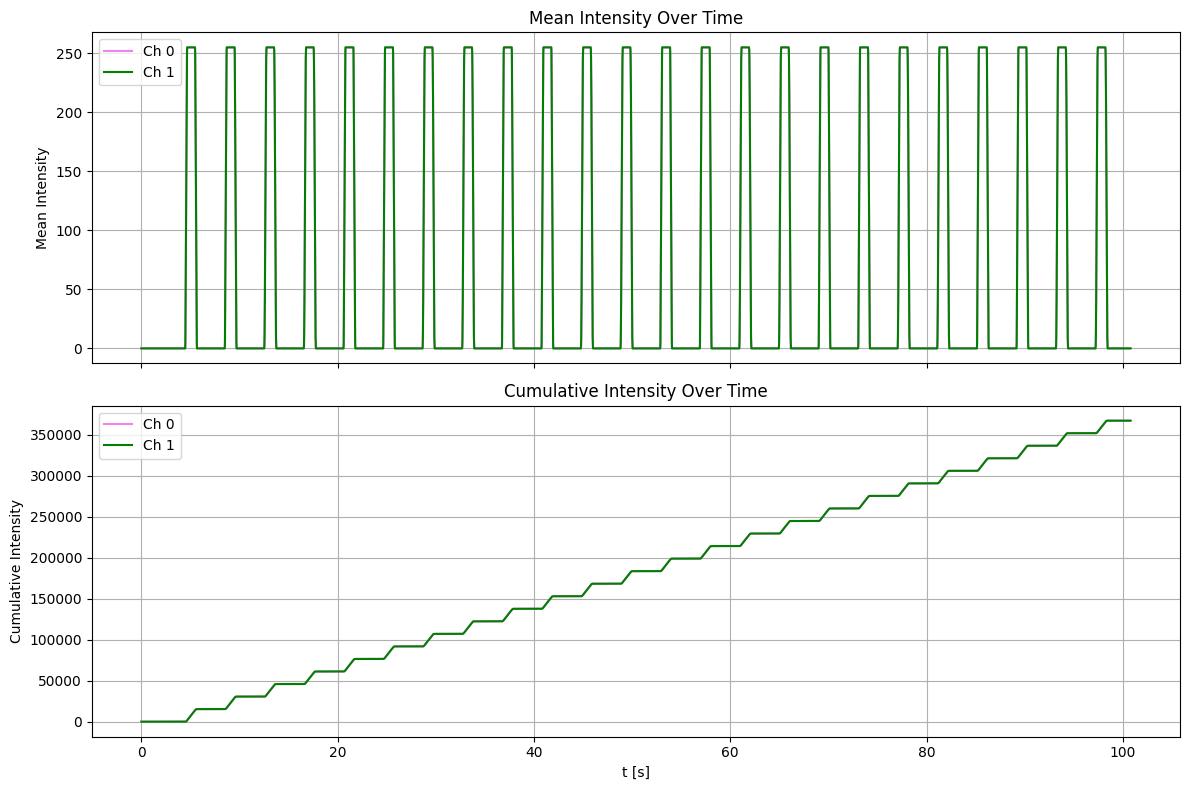

{'pix_size_um': 42.857142857142854,
 'mov_dxy': [40, 40],
 'mov_dxy_um': [1714.2857142857142, 1714.2857142857142],
 'dt_fr_s': 0.016666666666666666,
 'nCh': 2}

In [14]:
DS_intens, DS_intens_cumul = stim_movies.calc_intensity_trace(
    mov_DS, params, _range_s=[0, -1], _field_xy_um=[0,0], _field_size_um=[95*2.0, 95*2.0],
    _plot=True, _verbose=True
)
params

### Flattening movies 

In [ ]:
mov_flat = stim_movies.flatten_movie(mov_DS, params, _range_s=[0, 25], _plot=True)
